In [ ]:
# ============================================
# PROJECT 2: BANK CUSTOMER CHURN ANALYSIS
# Analyst: Abijah Kabiro
# Dataset: Churn Modelling (Kaggle)
# ============================================

# ============================================
# PHASE 1: BUSINESS UNDERSTANDING & DATASET OVERVIEW
# ============================================

# Step 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Step 2 — Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# Step 3 — Show CSV files in Drive
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file.endswith('.csv'):
            print(os.path.join(root, file))

# Step 4 — Load Data
df = pd.read_csv('/content/drive/MyDrive/Churn_Modelling.csv')
print("Dataset Shape:", df.shape)
print(df.head())

# ============================================
# PHASE 2: DATA CLEANING
# ============================================

print("=" * 40)
print("1. DATASET SHAPE")
print("=" * 40)
print(df.shape)

print("\n" + "=" * 40)
print("2. MISSING VALUES")
print("=" * 40)
print(df.isnull().sum())

print("\n" + "=" * 40)
print("3. DUPLICATE ROWS")
print("=" * 40)
print("Number of duplicates:", df.duplicated().sum())

print("\n" + "=" * 40)
print("4. DATA TYPES")
print("=" * 40)
print(df.dtypes)

print("\n" + "=" * 40)
print("5. BASIC STATISTICS")
print("=" * 40)
print(df.describe())

# Drop Irrelevant Columns
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])
print("\nRemaining columns:", df.columns.tolist())
print("New shape:", df.shape)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Churn_Modelling.csv
Dataset Shape: (10000, 14)
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82      

In [ ]:
# PHASE 3: EDA(Exploratory Data Analysis)
# Recreate AgeGroup Column
df['AgeGroup'] = pd.cut(df['Age'],
                         bins=[0, 30, 40, 50, 60, 100],
                         labels=['<30', '30-40', '40-50', '50-60', '60+'])
# PART A: CHURN OVERVIEW

# 1. Check Churn count
churn_counts = df['Exited'].value_counts()
churn_labels = ['Stayed (0)', 'Churned (1)']

print("=" * 40)
print("CHURN DISTRIBUTION")
print("=" * 40)
print(f"Stayed:  {churn_counts[0]} customers ({churn_counts[0]/len(df)*100:.1f}%)")
print(f"Churned: {churn_counts[1]} customers ({churn_counts[1]/len(df)*100:.1f}%)")


CHURN DISTRIBUTION
Stayed:  7963 customers (79.6%)
Churned: 2037 customers (20.4%)


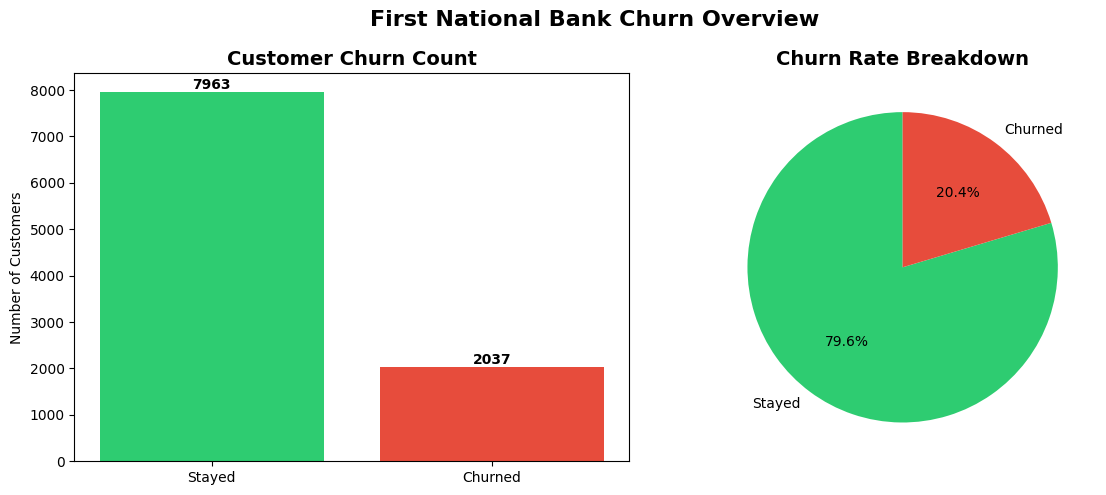


Key Finding: 1 in every 5 customers has left First National Bank.


In [ ]:
# 2. Visualizing the churn distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar(['Stayed', 'Churned'], churn_counts, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Customer Churn Count', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts, labels=['Stayed', 'Churned'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90)
axes[1].set_title('Churn Rate Breakdown', fontsize=14, fontweight='bold')

plt.suptitle('First National Bank Churn Overview', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey Finding: 1 in every 5 customers has left First National Bank.")

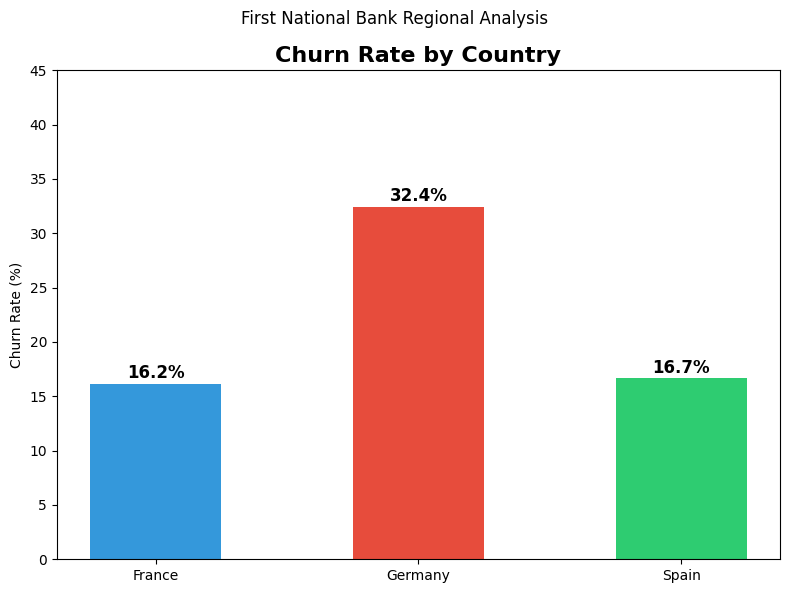

Churn Rate by Country:
Geography
France     16.2
Germany    32.4
Spain      16.7
Name: Exited, dtype: float64


In [ ]:
# PART B: CHECK WHO IS CHURNING?
# 1.CHURN BY GEOGRAPHY


geo_churn = df.groupby('Geography')['Exited'].mean() * 100

plt.figure(figsize=(8, 6))
bars = plt.bar(geo_churn.index, geo_churn.values,
               color=['#3498db', '#e74c3c', '#2ecc71'],
               width=0.5)
plt.title('Churn Rate by Country', fontsize=16, fontweight='bold')
plt.suptitle('First National Bank Regional Analysis', fontsize=12)
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 45)

for bar, val in zip(bars, geo_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             val + 0.5, f'{val:.1f}%',
             ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()
# Print exact numbers
print("Churn Rate by Country:")
print(geo_churn.round(1))



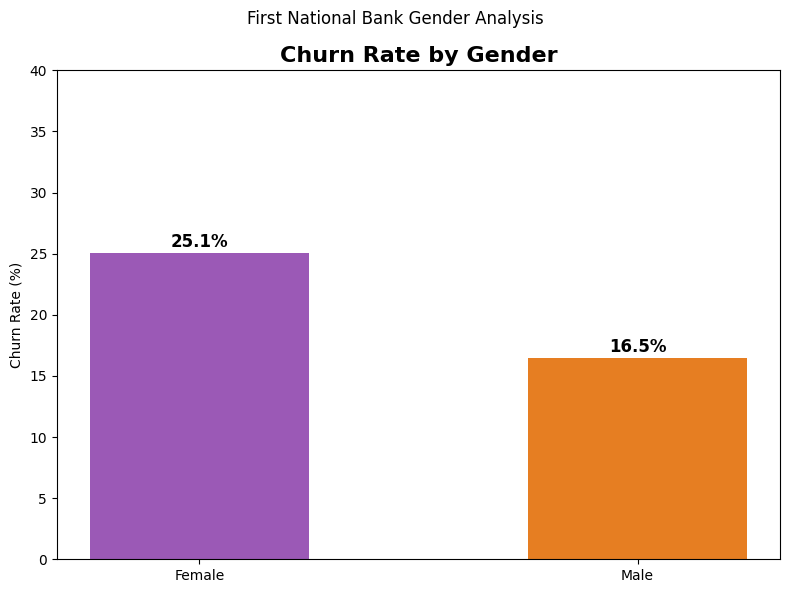


Churn Rate by Gender:
Gender
Female    25.1
Male      16.5
Name: Exited, dtype: float64


In [ ]:
# 2.CHURN BY GENDER
gender_churn = df.groupby('Gender')['Exited'].mean() * 100

plt.figure(figsize=(8, 6))
bars = plt.bar(gender_churn.index, gender_churn.values,
               color=['#9b59b6', '#e67e22'],
               width=0.5)
plt.title('Churn Rate by Gender', fontsize=16, fontweight='bold')
plt.suptitle('First National Bank Gender Analysis', fontsize=12)
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 40)

for bar, val in zip(bars, gender_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             val + 0.5, f'{val:.1f}%',
             ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()
print("\nChurn Rate by Gender:")
print(gender_churn.round(1))

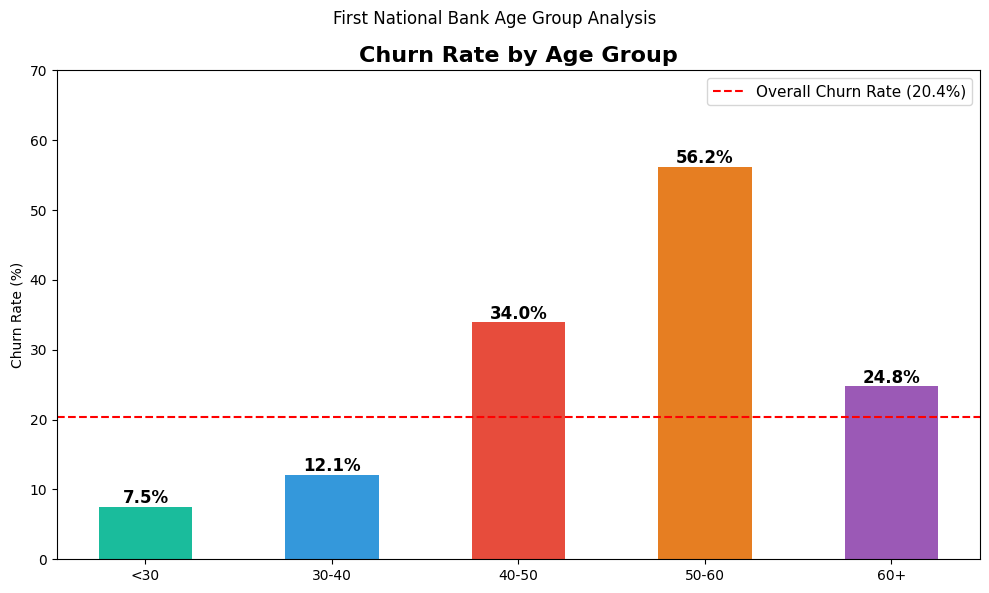


Churn Rate by Age Group:
AgeGroup
<30       7.5
30-40    12.1
40-50    34.0
50-60    56.2
60+      24.8
Name: Exited, dtype: float64


In [ ]:
# 3.CHURN BY AGE GROUP
df['AgeGroup'] = pd.cut(df['Age'],
                         bins=[0, 30, 40, 50, 60, 100],
                         labels=['<30', '30-40', '40-50', '50-60', '60+'])

age_churn = df.groupby('AgeGroup', observed=True)['Exited'].mean() * 100

plt.figure(figsize=(10, 6))
bars = plt.bar(age_churn.index.astype(str), age_churn.values,
               color=['#1abc9c', '#3498db', '#e74c3c', '#e67e22', '#9b59b6'],
               width=0.5)
plt.title('Churn Rate by Age Group', fontsize=16, fontweight='bold')
plt.suptitle('First National Bank Age Group Analysis', fontsize=12)
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 70)

for bar, val in zip(bars, age_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             val + 0.5, f'{val:.1f}%',
             ha='center', fontweight='bold', fontsize=12)

# Add a reference line for overall churn rate
plt.axhline(y=20.4, color='red', linestyle='--', linewidth=1.5,
            label='Overall Churn Rate (20.4%)')
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

print("\nChurn Rate by Age Group:")
print(age_churn.round(1))

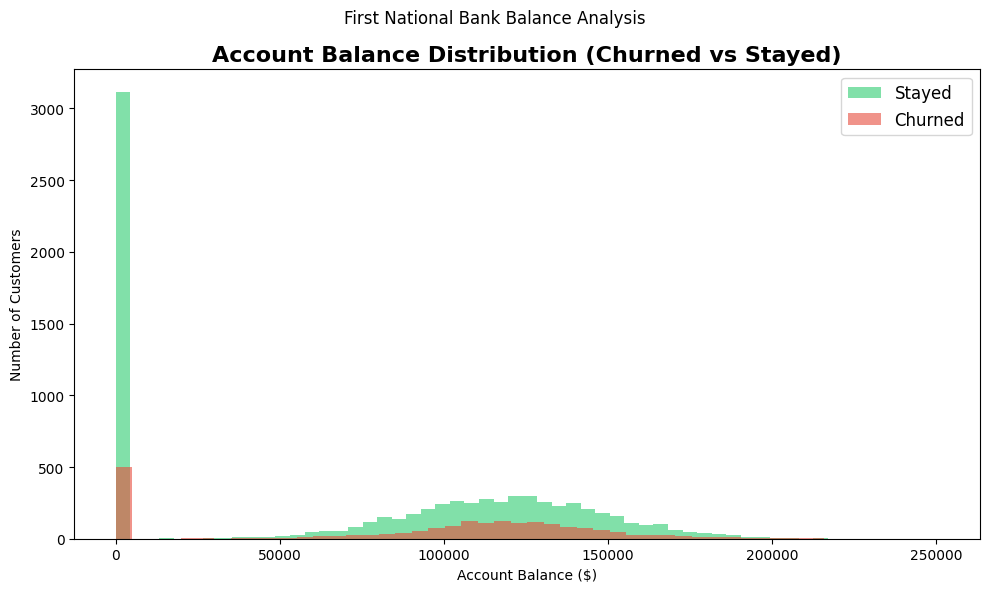

AVERAGE BALANCE (CHURNED VS STAYED)
Stayed:  $72,745.30
Churned: $91,108.54

ZERO BALANCE CUSTOMERS
Zero balance who Stayed:  3117
Zero balance who Churned: 500


In [ ]:
# PART C: CHECK WHY THEY ARE CHURNING

# 1.CHURN BY ACCOUNT BALANCE

plt.figure(figsize=(10, 6))

# Plot balance distribution for churned vs stayed
df[df['Exited'] == 0]['Balance'].plot(kind='hist',
                                       bins=50,
                                       alpha=0.6,
                                       color='#2ecc71',
                                       label='Stayed')
df[df['Exited'] == 1]['Balance'].plot(kind='hist',
                                       bins=50,
                                       alpha=0.6,
                                       color='#e74c3c',
                                       label='Churned')

plt.title('Account Balance Distribution (Churned vs Stayed)',
          fontsize=16, fontweight='bold')
plt.suptitle('First National Bank Balance Analysis', fontsize=12)
plt.xlabel('Account Balance ($)')
plt.ylabel('Number of Customers')
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# Print exact numbers
print("=" * 40)
print("AVERAGE BALANCE (CHURNED VS STAYED)")
print("=" * 40)
avg_balance = df.groupby('Exited')['Balance'].mean()
print(f"Stayed:  ${avg_balance[0]:,.2f}")
print(f"Churned: ${avg_balance[1]:,.2f}")

# Zero balance analysis
zero_balance = df[df['Balance'] == 0]['Exited'].value_counts()
print("\n" + "=" * 40)
print("ZERO BALANCE CUSTOMERS")
print("=" * 40)
print(f"Zero balance who Stayed:  {zero_balance[0]}")
print(f"Zero balance who Churned: {zero_balance[1]}")

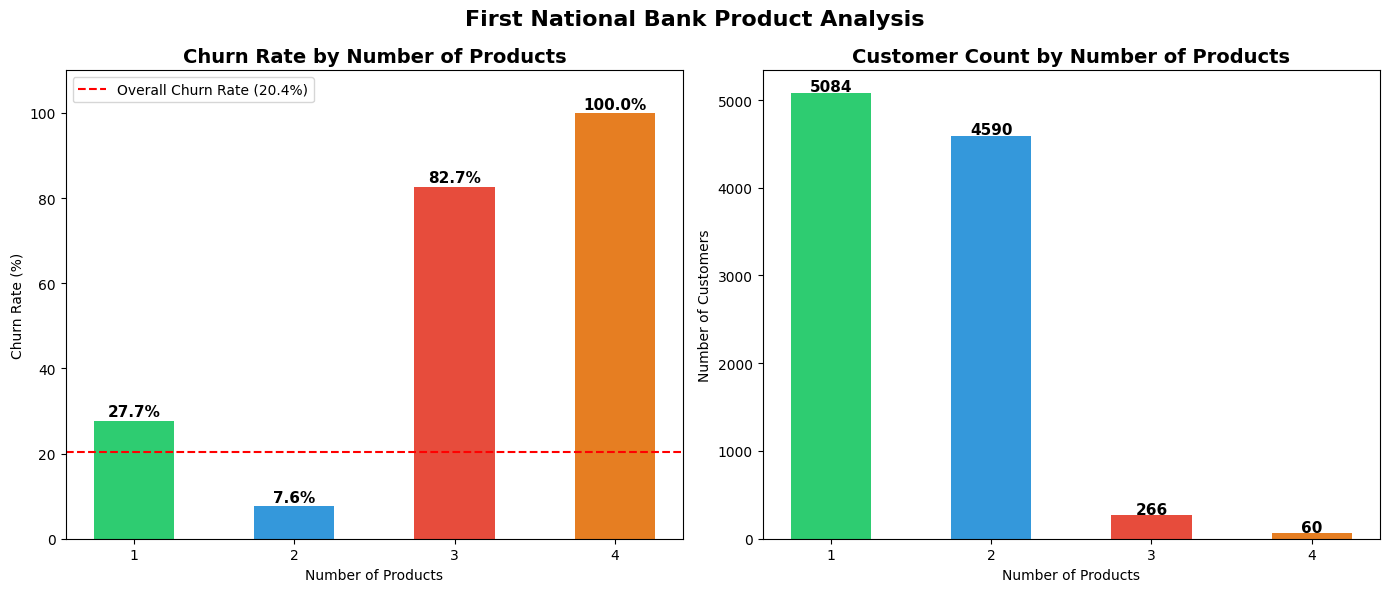

CHURN RATE BY NUMBER OF PRODUCTS
NumOfProducts
1     27.7
2      7.6
3     82.7
4    100.0
Name: Exited, dtype: float64

CUSTOMER COUNT BY NUMBER OF PRODUCTS
NumOfProducts
1    5084
2    4590
3     266
4      60
Name: Exited, dtype: int64


In [ ]:
# 2.CHURN BY NUMBER OF PRODUCTS
product_churn = df.groupby('NumOfProducts')['Exited'].mean() * 100
product_count = df.groupby('NumOfProducts')['Exited'].count()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1 — Churn Rate by Number of Products
bars = axes[0].bar(product_churn.index.astype(str),
                    product_churn.values,
                    color=['#2ecc71', '#3498db', '#e74c3c', '#e67e22'],
                    width=0.5)
axes[0].set_title('Churn Rate by Number of Products',
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Products')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, 110)
axes[0].axhline(y=20.4, color='red', linestyle='--',
                linewidth=1.5, label='Overall Churn Rate (20.4%)')
axes[0].legend()
for bar, val in zip(bars, product_churn.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 val + 1, f'{val:.1f}%',
                 ha='center', fontweight='bold', fontsize=11)

# Chart 2 — Customer Count by Number of Products
bars2 = axes[1].bar(product_count.index.astype(str),
                     product_count.values,
                     color=['#2ecc71', '#3498db', '#e74c3c', '#e67e22'],
                     width=0.5)
axes[1].set_title('Customer Count by Number of Products',
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Products')
axes[1].set_ylabel('Number of Customers')
for bar, val in zip(bars2, product_count.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 val + 20, str(val),
                 ha='center', fontweight='bold', fontsize=11)

plt.suptitle('First National Bank Product Analysis',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print exact numbers
print("=" * 40)
print("CHURN RATE BY NUMBER OF PRODUCTS")
print("=" * 40)
print(product_churn.round(1))
print("\nCUSTOMER COUNT BY NUMBER OF PRODUCTS")
print(product_count)

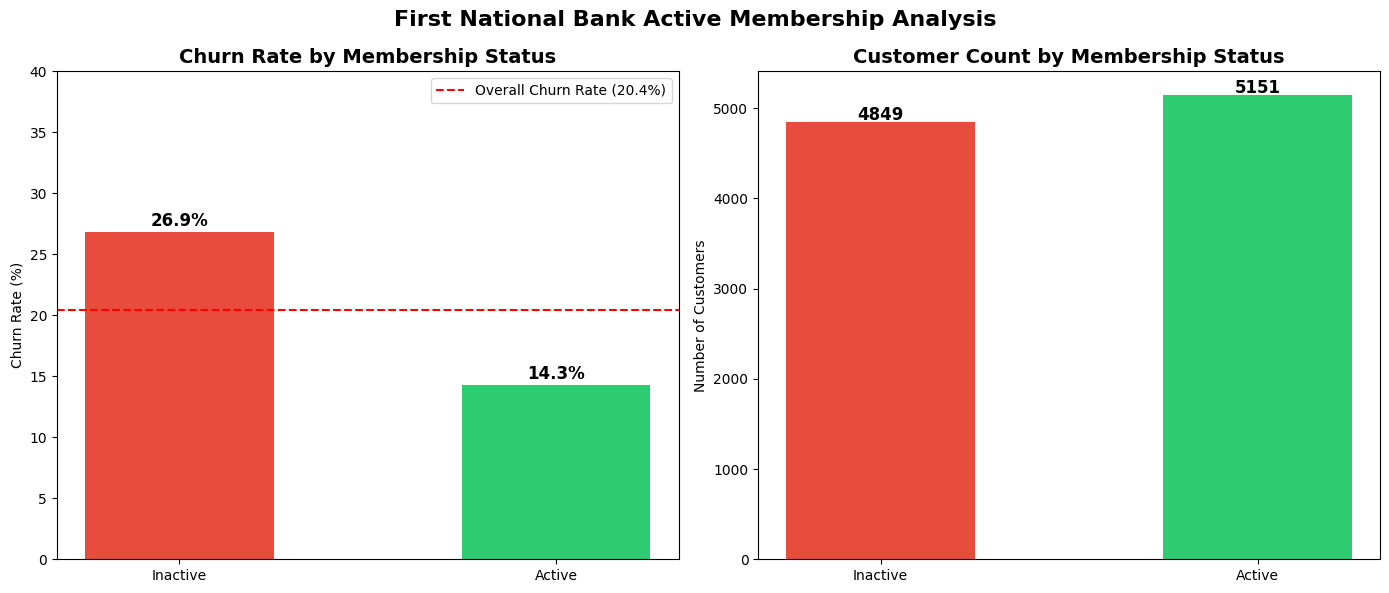

CHURN RATE BY MEMBERSHIP STATUS
Inactive Members: 26.9%
Active Members:   14.3%

CUSTOMER COUNT
Inactive: 4849
Active:   5151


In [ ]:
#3. CHURN BY ACTIVE MEMBERSHIP
active_churn = df.groupby('IsActiveMember')['Exited'].mean() * 100
active_labels = ['Inactive', 'Active']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1 — Churn Rate
bars = axes[0].bar(active_labels, active_churn.values,
                    color=['#e74c3c', '#2ecc71'],
                    width=0.5)
axes[0].set_title('Churn Rate by Membership Status',
                   fontsize=14, fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, 40)
axes[0].axhline(y=20.4, color='red', linestyle='--',
                linewidth=1.5, label='Overall Churn Rate (20.4%)')
axes[0].legend()
for bar, val in zip(bars, active_churn.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 val + 0.5, f'{val:.1f}%',
                 ha='center', fontweight='bold', fontsize=12)

# Chart 2 — Customer Count
active_count = df.groupby('IsActiveMember')['Exited'].count()
bars2 = axes[1].bar(active_labels, active_count.values,
                     color=['#e74c3c', '#2ecc71'],
                     width=0.5)
axes[1].set_title('Customer Count by Membership Status',
                   fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Customers')
for bar, val in zip(bars2, active_count.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 val + 20, str(val),
                 ha='center', fontweight='bold', fontsize=12)

plt.suptitle('First National Bank Active Membership Analysis',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print exact numbers
print("=" * 40)
print("CHURN RATE BY MEMBERSHIP STATUS")
print("=" * 40)
print(f"Inactive Members: {active_churn[0]:.1f}%")
print(f"Active Members:   {active_churn[1]:.1f}%")
print("\nCUSTOMER COUNT")
print(f"Inactive: {active_count[0]}")
print(f"Active:   {active_count[1]}")

In [ ]:
# ============================================
# PHASE 4: CHURN PREDICTION MODEL
# Step 4A: Prepare Data for Modelling
# ============================================

# Import the tools we need for machine learning
from sklearn.model_selection import train_test_split      # Splits data into training and testing sets
from sklearn.preprocessing import StandardScaler          # Standardizes numerical features
from sklearn.linear_model import LogisticRegression       # Logistic Regression algorithm
from sklearn.metrics import (
    accuracy_score,                                       # Calculates prediction accuracy
    confusion_matrix,                                     # Creates a confusion matrix
    classification_report,                               # Shows precision, recall and F1-score
    ConfusionMatrixDisplay                               # Displays the confusion matrix visually
)

# ======================================================
# STEP 1: PREPARE THE DATA
# ======================================================

# Create a copy of the original dataset so we don't modify it
df_model = df.copy()

# Convert categorical (text) columns into numerical columns
# Machine learning models cannot understand text such as
# "Male", "Female", "France", "Germany", etc.
# pd.get_dummies() creates binary (0/1) columns instead.
df_model = pd.get_dummies(
    df_model,
    columns=['Geography', 'Gender'],
    drop_first=True      # Drops one category to avoid redundant information
)

# Remove the AgeGroup column if it exists.
# We created it earlier only for visualization during EDA.
# The model already has the actual Age column.
if 'AgeGroup' in df_model.columns:
    df_model = df_model.drop(columns=['AgeGroup'])


# ======================================================
# STEP 2: DEFINE FEATURES (X) AND TARGET (y)
# ======================================================

# X contains all the information the model will use
# to predict whether a customer will churn.
X = df_model.drop(columns=['Exited'])

# y is the target variable.
# This is what the model is trying to predict.
# 0 = Customer Stayed
# 1 = Customer Churned
y = df_model['Exited']


# ======================================================
# STEP 3: SPLIT THE DATA
# ======================================================

# Split the dataset into:
# 80% Training Data -> used to teach the model
# 20% Testing Data -> used to evaluate the model

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # Reserve 20% for testing
    random_state=42     # Makes the split reproducible
)


# ======================================================
# STEP 4: SCALE THE FEATURES
# ======================================================

# Create a StandardScaler object.
# Scaling makes numerical features have similar ranges,
# which helps algorithms like Logistic Regression learn better.
scaler = StandardScaler()

# Learn the scaling parameters (mean and standard deviation)
# from the TRAINING data, then scale it.
X_train_scaled = scaler.fit_transform(X_train)

# Apply the SAME scaling to the TESTING data.
# We only transform here because we don't want the model
# to learn anything from the test data.
X_test_scaled = scaler.transform(X_test)


# ======================================================
# STEP 5: CONFIRM DATA PREPARATION
# ======================================================

print("=" * 40)
print("DATA PREPARATION COMPLETE")
print("=" * 40)

# Display how many features are being used
print(f"Total features:    {X.shape[1]}")

# Display the number of training records
print(f"Training samples:  {X_train.shape[0]}")

# Display the number of testing records
print(f"Testing samples:   {X_test.shape[0]}")

# Display the names of all features used by the model
print("\nFeatures used:")
print(X.columns.tolist())

DATA PREPARATION COMPLETE
Total features:    11
Training samples:  8000
Testing samples:   2000

Features used:
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']


In [ ]:
# ============================================
# PHASE 4: CHURN PREDICTION MODEL
# Step 4B: Train the Model
# ============================================

# ======================================================
# STEP 1: CREATE AND TRAIN THE MODEL
# ======================================================
# Create a Logistic Regression model
# max_iter=1000 gives the model enough cycles to learn
model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model using the training data
# The model learns the relationship between
# customer features and whether they churned
model.fit(X_train_scaled, y_train)

print("=" * 40)
print("MODEL TRAINING COMPLETE")
print("=" * 40)
print("Model successfully trained on 8,000 customers!")
print("Ready to make predictions on 2,000 test customers.")

MODEL TRAINING COMPLETE
Model successfully trained on 8,000 customers!
Ready to make predictions on 2,000 test customers.


In [ ]:
# PHASE 4 — Step 4C-1: Accuracy Score


# Use the trained model to predict churn outcomes
# for the 2,000 customers in the test set.
# These are customers the model has NEVER seen before.
y_pred = model.predict(X_test_scaled)

# Compare the model's predictions (y_pred)
# against the actual outcomes (y_test)
# to calculate how often the model was correct.
accuracy = accuracy_score(y_test, y_pred)

print("=" * 40)
print("MODEL ACCURACY")
print("=" * 40)

# Multiply by 100 to convert from decimal to percentage
print(f"Accuracy: {accuracy * 100:.2f}%")

MODEL ACCURACY
Accuracy: 81.10%


In [ ]:
# ============================================
# PHASE 4 — Step 4C-2: Classification Report
# ============================================

# The classification report gives us 3 key metrics:
#
# PRECISION — Of all customers the model predicted
#             would churn, how many actually did?
#             High precision = fewer false alarms.
#
# RECALL    — Of all customers who actually churned,
#             how many did the model correctly catch?
#             High recall = fewer missed churners.
#
# F1-SCORE  — A balance between precision and recall.
#             The higher the better (max = 1.0).

print("=" * 40)
print("CLASSIFICATION REPORT")
print("=" * 40)
print(classification_report(y_test, y_pred,
      target_names=['Stayed (0)', 'Churned (1)']))

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Stayed (0)       0.83      0.96      0.89      1607
 Churned (1)       0.55      0.20      0.29       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



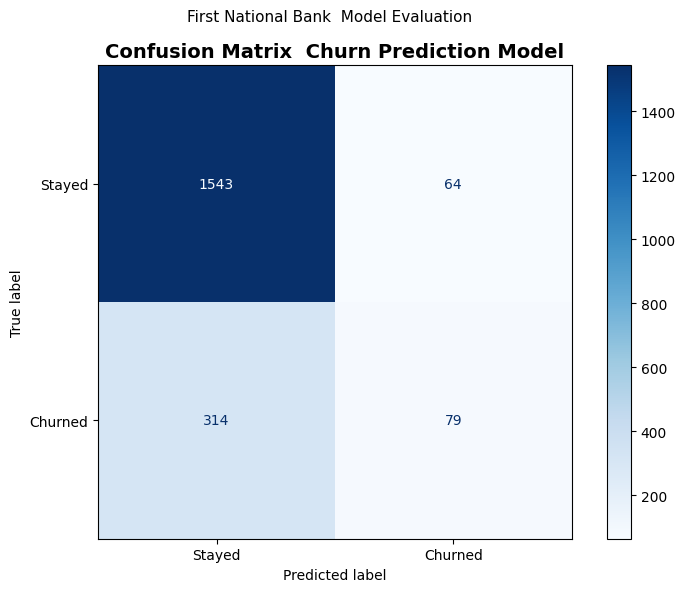

In [ ]:
# ============================================
# PHASE 4 — Step 4C-3: Confusion Matrix
# ============================================

# A confusion matrix shows us 4 outcomes:
#
# TRUE POSITIVE  (top left)  — Predicted Stayed,  Actually Stayed  ✅
# FALSE POSITIVE (top right) — Predicted Churned, Actually Stayed  ❌
# FALSE NEGATIVE (bottom left)— Predicted Stayed, Actually Churned ❌
# TRUE NEGATIVE  (bottom right)— Predicted Churned,Actually Churned✅
#
# We want the diagonal (top-left to bottom-right)
# to have the highest numbers — those are correct predictions.

plt.figure(figsize=(8, 6))

# Generate the confusion matrix from actual vs predicted values
cm = confusion_matrix(y_test, y_pred)

# Display the matrix as a visual heatmap
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Stayed', 'Churned'])
disp.plot(cmap='Blues', ax=plt.gca())

plt.title('Confusion Matrix  Churn Prediction Model',
          fontsize=14, fontweight='bold')
plt.suptitle('First National Bank  Model Evaluation', fontsize=11)
plt.tight_layout()
plt.show()

FEATURE IMPORTANCE
(Which factors drive churn the most?)
          Feature  Coefficient
              Age     0.754217
   IsActiveMember    -0.533432
Geography_Germany     0.337190
      Gender_Male    -0.264718
          Balance     0.161139
      CreditScore    -0.067683
    NumOfProducts    -0.060278
           Tenure    -0.042637
  Geography_Spain     0.038960
  EstimatedSalary     0.015744
        HasCrCard    -0.010236


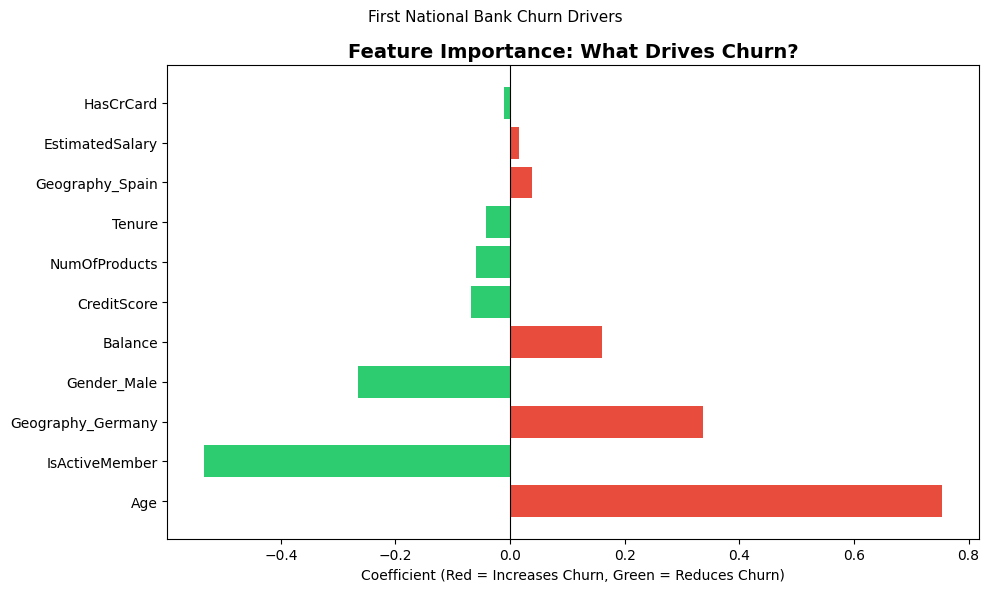

In [ ]:
# ============================================
# PHASE 4 — Step 4C-4: Feature Importance
# ============================================

# In Logistic Regression, each feature is assigned
# a coefficient (weight) that shows how strongly
# it influences the churn prediction.
#
# POSITIVE coefficient = increases churn probability
# NEGATIVE coefficient = decreases churn probability
#
# The larger the absolute value, the more powerful
# that feature is in driving the prediction.

# Build a dataframe of features and their coefficients
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

# Add absolute value column to rank by strength
# regardless of direction (positive or negative)
importance['AbsCoefficient'] = importance['Coefficient'].abs()

# Sort from most to least influential
importance = importance.sort_values('AbsCoefficient', ascending=False)

print("=" * 40)
print("FEATURE IMPORTANCE")
print("(Which factors drive churn the most?)")
print("=" * 40)
print(importance[['Feature', 'Coefficient']].to_string(index=False))

# Colour bars red if the feature INCREASES churn
# Colour bars green if the feature REDUCES churn
colors = ['#e74c3c' if c > 0 else '#2ecc71'
          for c in importance['Coefficient']]

plt.figure(figsize=(10, 6))
plt.barh(importance['Feature'], importance['Coefficient'],
         color=colors)
plt.title('Feature Importance: What Drives Churn?',
          fontsize=14, fontweight='bold')
plt.suptitle('First National Bank Churn Drivers', fontsize=11)
plt.xlabel('Coefficient (Red = Increases Churn, Green = Reduces Churn)')

# Draw a vertical line at zero as a reference point
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()